# Retail Sales Analysis and Customer Insights

Objective:
Analyze retail sales data to uncover customer purchasing behavior,
sales trends, and category performance using Python.

## Import Libraries

In [65]:
## Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt 

## Data Loading

In [66]:
# Loading the retail sales dataset
df = pd.read_csv("retail_sales_dataset.csv")

In [67]:
## Viewing the DataFrame
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


## Data Cleaning

In [68]:
# Dropping duplicate rows
df.drop_duplicates(inplace=True)

In [69]:
# Identifying missing values
df.isnull().sum()   

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [70]:
# Describing the dataset
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


## Feature Engineering

In [71]:
## Converting 'Date' column to datetime format
df["Date"] = pd.to_datetime(df["Date"])

## Exploratory Data Analysis

### Univariate Analysis 

#### Distribution Of Total Sales amount

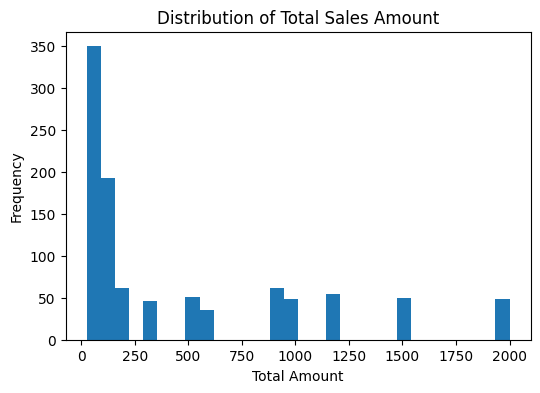

In [72]:
## Distribution of Total Sales Amount

plt.figure(figsize=(6,4))
plt.hist(df["Total Amount"], bins=30)
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.title("Distribution of Total Sales Amount")
plt.show()


#### Insights 

Most sales amounts are small lie between 0-150 

High value Transactions are low 

Presence of Outliers 

#### Outlier detection


#### Problem : Are there outliers in sales amount?

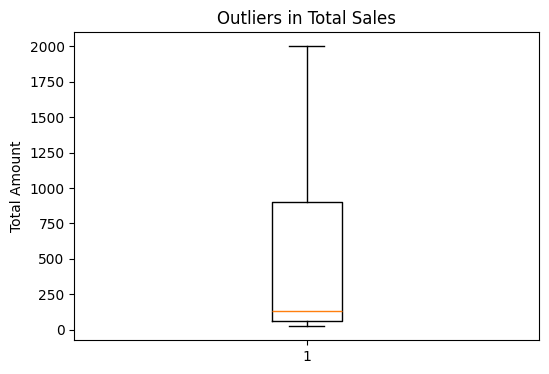

In [73]:
# Outlier detection using box plot

plt.figure(figsize=(6,4))
plt.boxplot(df["Total Amount"])
plt.ylabel("Total Amount")
plt.title("Outliers in Total Sales")
plt.show()


In [74]:
Q1 = df["Total Amount"].quantile(0.25)
Q3 = df["Total Amount"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"Lower Bound: {lower}")
print(f"Upper Bound: {upper}")
print(f"IQR: {IQR}")


Q1: 60.0
Q3: 900.0
Lower Bound: -1200.0
Upper Bound: 2160.0
IQR: 840.0


#### Product Category Distribution

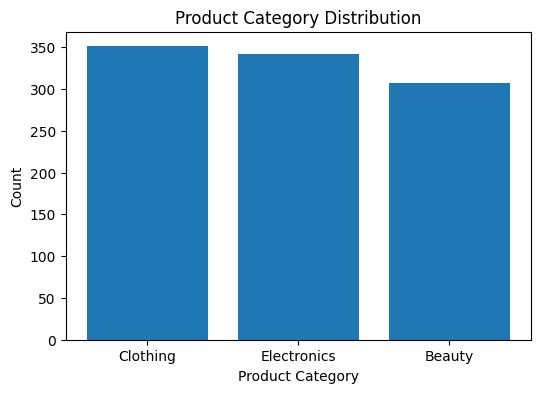

In [75]:
## Product Category Distribution
category_count = df["Product Category"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(category_count.index, category_count.values)
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.title("Product Category Distribution")
plt.show()


#### Insights

Balanced Distribution between Clothing,Electronics,Beauty

Clothing is most frequent , Beauty is less frequent 





### Bivariate Analysis


#### Average spending by Gender

##### Problem: Do men or women spend more?

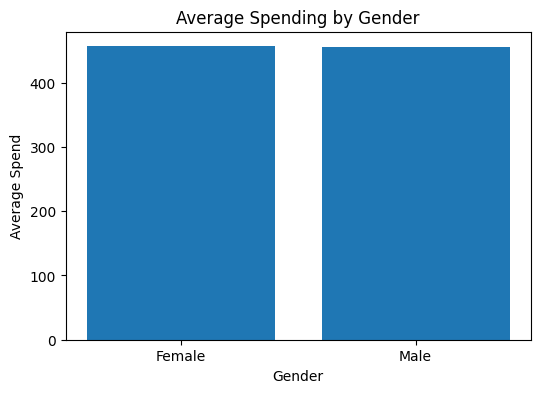

In [76]:
## Average Spending by Gender

gender_avg = df.groupby("Gender")["Total Amount"].mean()
plt.figure(figsize=(6,4))
plt.bar(gender_avg.index, gender_avg.values)
plt.xlabel("Gender")
plt.ylabel("Average Spend")
plt.title("Average Spending by Gender")
plt.show()


#### Insights 
Male and female customers have similar average spending patterns.

#### Product Category vs Revenue

##### Problem : Which product category generates highest revenue?

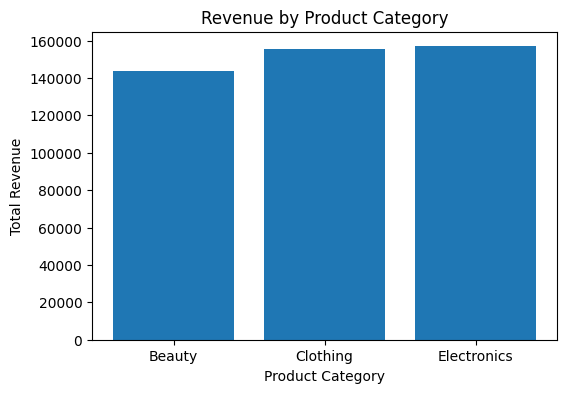

In [77]:
## Revenue by Product Category
category_sales = df.groupby("Product Category")["Total Amount"].sum()

plt.figure(figsize=(6,4))
plt.bar(category_sales.index, category_sales.values)
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.title("Revenue by Product Category")
plt.show()


#### Insights 
Electronics generates the highest revenue

Clothing is a strong second

Beauty has the lowest total revenue



### MultiVariate Analysis

#### Monthly Sales Trend

Problem : Which month has peak sales ? 

Problem : Are sales increasing or decreasing over time?

In [78]:
df["Month"] = df["Date"].dt.month_name()
monthly_sales = df.groupby("Month")["Total Amount"].sum()
print(monthly_sales)

Month
April        33870
August       36960
December     44690
February     44060
January      36980
July         35465
June         36715
March        28990
May          53150
November     34920
October      46580
September    23620
Name: Total Amount, dtype: int64


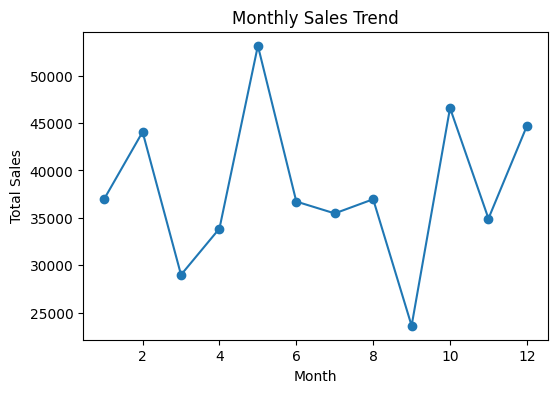

In [79]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month
monthly_sales = df.groupby("Month")["Total Amount"].sum()

plt.figure(figsize=(6,4))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")
plt.show()


#### Insights 
Sales Fluctuate over Time

May month has highest sales (Possible Reasons : Discount,Season Demand)

September has lowest sales (Possible Reasons : OffSeason,Fewer Discount/No Discount )

#### Age group vs Revenue

##### Problem : Which age group contributes most revenue?

In [80]:
## Sales by Age Group
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0,20,45,60,100],
    labels=["Young","Adult","Middle_Aged","Senior"]
)
age_sales = df.groupby("Age_Group")["Total Amount"].sum()
print(age_sales)

Age_Group
Young           34730
Adult          240170
Middle_Aged    147875
Senior          33225
Name: Total Amount, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7948\3216251116.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_sales = df.groupby("Age_Group")["Total Amount"].sum()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_7948\4202905292.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_sales = df.groupby("Age_Group")["Total Amount"].sum()


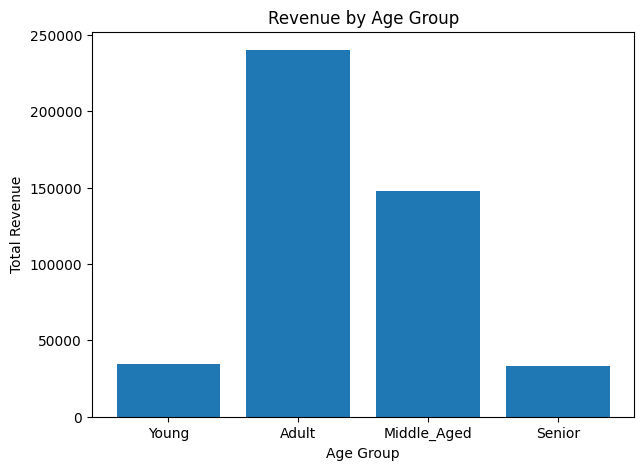

In [81]:
## Sales by Age Group
age_sales = df.groupby("Age_Group")["Total Amount"].sum()

## Plotting Revenue by Age Group
plt.figure(figsize=(7,5))
plt.bar(age_sales.index, age_sales.values)
plt.xlabel("Age Group")
plt.ylabel("Total Revenue")
plt.title("Revenue by Age Group")
plt.show()


#### Insights
Adults contribute to higher revenue production ( Age = 20 to 45 )

Middle Aged contribute second largest revenue  ( Age = 45 to 70)

Young and Seniors group contribute minimal revenue

Prioritize Adults for higher revenue

For Young Category provide offers,discounts 

#### Correlation

#### Problem : Is revenue driven by price or quantity?

                     Age  Quantity  Price per Unit  Total Amount
Age             1.000000 -0.023737       -0.038423     -0.060568
Quantity       -0.023737  1.000000        0.017501      0.373707
Price per Unit -0.038423  0.017501        1.000000      0.851925
Total Amount   -0.060568  0.373707        0.851925      1.000000


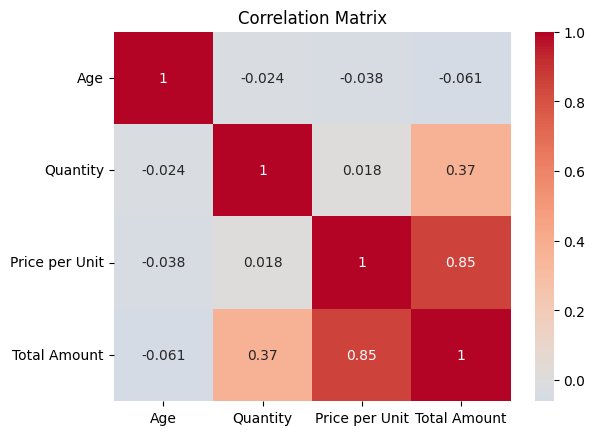

In [82]:
## Correlation Matrix
import seaborn as sns
corr = df[["Age","Quantity","Price per Unit","Total Amount"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
print(corr)


#### Insights 
Total Amount is strongly driven by Price per Unit

Quantity has a moderate impact on Total Amount

Age has almost no relationship with spending

### Problem Solution


##### Problem 1: Which product category generates highest revenue?

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


<Axes: title={'center': 'Revenue by Product Category'}, xlabel='Product Category', ylabel='Total Revenue'>

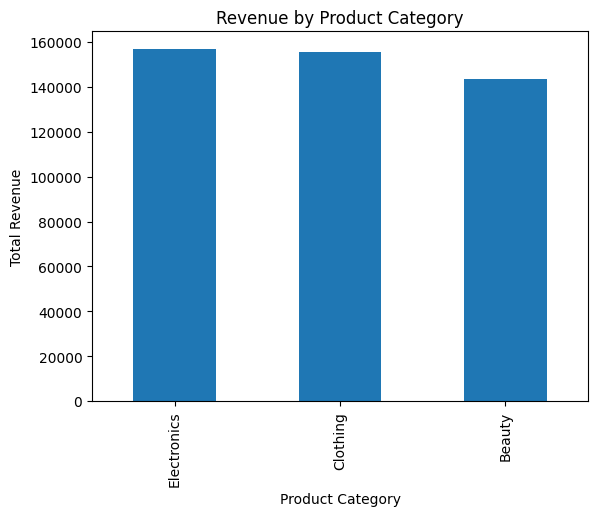

In [83]:
## Revenue by Product Category
category_sales = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)
print(category_sales)
## Plotting Revenue by Product Category
category_sales.plot(kind="bar", title="Revenue by Product Category", xlabel="Product Category", ylabel="Total Revenue")


## KPI Summary 

In [84]:
# KPI 1: Total Revenue
total_revenue = df['Total Amount'].sum()

# KPI 2: Total Transactions
total_transactions = len(df)

# KPI 3: Average Order Value
avg_order_value = df['Total Amount'].mean()

# KPI 4: Top Product Category
top_category = (
    df.groupby('Product Category')['Total Amount']
    .sum()
    .idxmax()
)

# KPI 5: Revenue from Top Category
top_category_revenue = (
    df.groupby('Product Category')['Total Amount']
    .sum()
    .max()
)

print("========== KPI SUMMARY ==========")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Total Transactions: {total_transactions}")
print(f"Average Order Value: ₹{avg_order_value:.2f}")
print(f"Top Product Category: {top_category}")
print(f"Revenue from Top Category: ₹{top_category_revenue:,.2f}")

========== KPI SUMMARY ==========
Total Revenue: ₹456,000.00
Total Transactions: 1000
Average Order Value: ₹456.00
Top Product Category: Electronics
Revenue from Top Category: ₹156,905.00


## Key Findings:

• Electronics generated the highest revenue.

• Adult customers (20–45 years) contributed the most sales.

• Revenue varied significantly across months.

• Price per Unit has the strongest impact on Total Amount.

• Male and female customers exhibit similar spending behavior.

This analysis helps identify customer trends and product performance,
supporting better business decisions.